# Model building

In [3]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split # Splits the dataset into training and testing sets.

from sklearn.linear_model import LogisticRegression # Builds a baseline classification model.
from sklearn.tree import DecisionTreeClassifier     # Creates a tree-based model.
from sklearn.ensemble import RandomForestClassifier # Combines many decision trees for better performance.

from sklearn.metrics import ( 
    accuracy_score,                 # Calculates prediction accuracy.
    confusion_matrix,               # Shows correct and incorrect predictions.
    classification_report           # Displays Precision, Recall, and F1-score.
)

In [4]:
# load updated dataset
df = pd.read_csv('../data/train_processed.csv')
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,-0.565736,0.432793,-0.473674,-0.502445,2
1,1,1,0,0.663861,0.432793,-0.473674,0.786845,0
2,1,3,0,-0.258337,-0.474545,-0.473674,-0.488854,2
3,1,1,0,0.433312,0.432793,-0.473674,0.420730,2
4,0,3,1,0.433312,-0.474545,-0.473674,-0.486337,2


In [5]:
# Separate Features and Target = Our Traget is "Survived"
# Everything else is a feature. becuase machine learning follow this structure 
#  Features (X)
#          ↓
# Machine Learning Model
#         ↓
# Predict Target (y)

X = df.drop('Survived',axis=1)
y = df['Survived']

In [6]:
# Train-Test Split. 80% training, 20% testing.
# Training teaches the model.
# Testing checks whether the model learned patterns or simply memorized the training data.

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
# Checking Shapes

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 7)
(179, 7)
(712,)
(179,)


In [8]:
# Train Logistic Regression
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train,y_train) # Fit means Learn from the training data.
# The model studies the relationship between features (X_train) and the target (y_train).


LogisticRegression(random_state=42)

In [9]:
# Make Predictions
y_pred_log = log_model.predict(X_test) 
# predict() uses the trained model to predict survival for passengers in the test set.

In [10]:
# Evaluate the Model
print("Accuracy:", accuracy_score(y_test, y_pred_log)) # Accuracy means The percentage of predictions that are correct.

Accuracy: 0.8100558659217877


In [11]:
# For Confusion Matrix
confusion_matrix(y_test, y_pred_log) 

array([[90, 15],
       [19, 55]])

In [12]:
# Confusion Matrix Interpretation

# - True Negatives (90): Correctly predicted passengers who did not survive.
# - False Positives (15): Incorrectly predicted survival for passengers who did not survive.
# - False Negatives (19): Incorrectly predicted non-survival for passengers who actually survived.
# - True Positives (55): Correctly predicted passengers who survived.

In [13]:
# Classification Report
print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [14]:
# Model Performance

# - Accuracy: 81%
# - The model correctly classified most passengers.
# - Precision for survivors is 79%, meaning most predicted survivors actually survived.
# - Recall for survivors is 74%, meaning the model identified about three-quarters of the actual survivors.
# - Overall, Logistic Regression provides a strong baseline model for this dataset.

# Decision Tree

In [15]:
# Creating Decision Tree Model
dt_model = DecisionTreeClassifier(random_state=42)

In [16]:
# Train the Model
dt_model.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [17]:
# Now the trained tree predicts survival for the 179 passengers in X_test.
y_pred_dt = dt_model.predict(X_test)

In [18]:
# Calculating  accuracy
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7821229050279329


In [19]:
# Decision Tree Accuracy = 78.21%

In [20]:
# Confusion Matrix
confusion_matrix(y_test,y_pred_dt)

array([[84, 21],
       [18, 56]])

In [21]:
# 84 → Correctly predicted non-survivors (True Negatives)
# 21 → Predicted survivor, but actually did not survive (False Positives)
# 18 → Predicted non-survivor, but actually survived (False Negatives)
# 56 → Correctly predicted survivors (True Positives)

In [22]:
# Classification report
print(classification_report(y_test,y_pred_dt))

              precision    recall  f1-score   support

           0       0.82      0.80      0.81       105
           1       0.73      0.76      0.74        74

    accuracy                           0.78       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.78      0.78      0.78       179



In [23]:
# Decision Tree Results

# - Accuracy: 78.21%
# - The Decision Tree correctly classified approximately 78% of the test passengers.
# - For survivors (Class 1), the model achieved 73% precision and 76% recall.
# - Compared with Logistic Regression, the Decision Tree performed worse in overall accuracy.
# - However, the Decision Tree achieved slightly higher recall for survivors.
# - The basic Decision Tree may require tuning to reduce overfitting and improve generalization.

# Random Forest

In [24]:
# A Random Forest is an ensemble model that builds many Decision Trees and combines their predictions

In [25]:
# Decision Tree 1 ──┐
# Decision Tree 2 ──┤
# Decision Tree 3 ──┤
# Decision Tree 4 ──┼──→ Random Forest → Final Prediction
# Decision Tree 5 ──┤
#        ...        │
# Decision Tree N ──┘

In [26]:
rf_model = RandomForestClassifier(
    n_estimators=100,                 # n_estimators=100 The Random Forest will create 100 Decision Trees
    random_state=42
)       

In [27]:
# Train the Random Forest
rf_model.fit(X_train,y_train)         # The model learns patterns from your training data.

RandomForestClassifier(random_state=42)

In [28]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)   # Now it predicts survival for your test data.

In [29]:
# Calculate Accuracy
print("Random Forest Accuracy:",accuracy_score(y_test,y_pred_rf))

Random Forest Accuracy: 0.8156424581005587


In [30]:
# Random Forest Accuracy = 81.56%

In [31]:
# Confusion Matrix
confusion_matrix(y_test,y_pred_rf)

array([[91, 14],
       [19, 55]])

In [32]:
# - True Negatives (91): 91 passengers who did not survive were correctly predicted as non-survivors.
# - False Positives (14): 14 passengers who did not survive were incorrectly predicted as survivors.
# - False Negatives (19): 19 passengers who survived were incorrectly predicted as non-survivors.
# - True Positives (55): 55 passengers who survived were correctly predicted as survivors.

# The model made 146 correct predictions out of 179 test passengers.

In [33]:
# Classification Report
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.81      0.82      0.81       179



In [34]:
### Classification Report

# - Accuracy: 82%
# - Class 0 F1-score: 85%
# - Class 1 F1-score: 77%
# - The Random Forest model performed well overall and achieved the highest accuracy among the three models tested.

# Compare All Three Models

In [35]:
results = pd.DataFrame({
    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)

    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.810056
1,Decision Tree,0.782123
2,Random Forest,0.815642


# Visualize Model Comparison

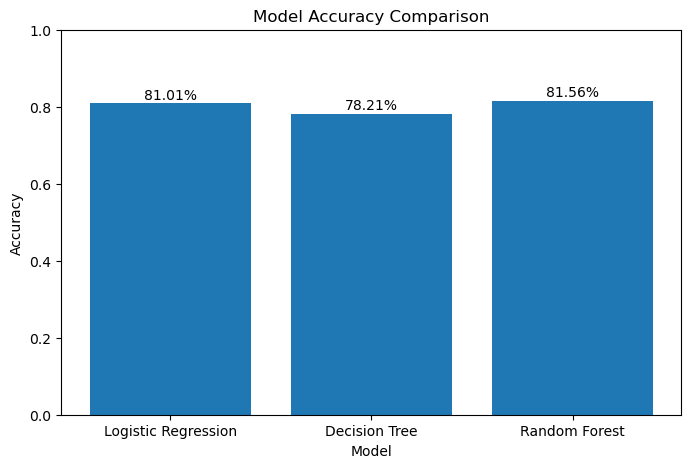

In [36]:
plt.figure(figsize=(8, 5))

bars = plt.bar(
    results["Model"],
    results["Accuracy"]
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

# "Write the accuracy value on top of each bar."
for bar, accuracy in zip(bars, results["Accuracy"]): # Take each bar and its matching accuracy value one by one.
    plt.text(                                        # puts that accuracy above each bar.
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{accuracy:.2%}",
        ha="center"
    )

plt.show()

# Overfitting Check

In [37]:
# For a classification model, .score() returns the accuracy.
log_train_accuracy = log_model.score(X_train,y_train)  # Calculate the accuracy of Logistic Regression on the training data.
log_test_accuracy = log_model.score(X_test,y_test)     # Calculate the accuracy on unseen test data

print("Logistic Regression")
print("Training Accuracy:", log_train_accuracy)
print("Testing Accuracy:", log_test_accuracy)

Logistic Regression
Training Accuracy: 0.800561797752809
Testing Accuracy: 0.8100558659217877


In [38]:
# Decision Tree

dt_train_accuracy = dt_model.score(X_train, y_train)
dt_test_accuracy = dt_model.score(X_test, y_test)

print("Decision Tree")
print("Training Accuracy:", dt_train_accuracy)
print("Testing Accuracy:", dt_test_accuracy)

Decision Tree
Training Accuracy: 0.9789325842696629
Testing Accuracy: 0.7821229050279329


In [39]:
rf_train_accuracy = rf_model.score(X_train, y_train)
rf_test_accuracy = rf_model.score(X_test, y_test)

print("Random Forest")
print("Training Accuracy:", rf_train_accuracy)
print("Testing Accuracy:", rf_test_accuracy)

Random Forest
Training Accuracy: 0.9789325842696629
Testing Accuracy: 0.8156424581005587


In [40]:
# Creating a Comparison Table

overfitting_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Training Accuracy": [
        log_train_accuracy,
        dt_train_accuracy,
        rf_train_accuracy
    ],
    "Testing Accuracy": [
        log_test_accuracy,
        dt_test_accuracy,
        rf_test_accuracy
    ]
})

overfitting_results

,Model,Training Accuracy,Testing Accuracy
0,Logistic Regression,0.800562,0.810056
1,Decision Tree,0.978933,0.782123
2,Random Forest,0.978933,0.815642


In [41]:
# Understand the Difference
# We'll calculate the gap:

overfitting_results["Accuracy Gap"] = (   
    overfitting_results["Training Accuracy"]
    - overfitting_results["Testing Accuracy"]
)

# The Accuracy Gap tells us how much better the model performs on training data than unseen data.

overfitting_results


,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Logistic Regression,0.800562,0.810056,-0.009494
1,Decision Tree,0.978933,0.782123,0.196810
2,Random Forest,0.978933,0.815642,0.163290


# Logistic regression

In [42]:
# Training: 80.06%
# Testing:  81.01%
# Gap:      -0.95%
# Conclusion: Logistic Regression is generalizing well and does not show significant overfitting.

# Decision Tree

In [43]:
# Training: 97.89%
# Testing:  78.21%
# Gap:      19.68%

# The tree has learned the training data extremely well but performs considerably worse on unseen data.
# Conclusion: The Decision Tree is strongly overfitting.

# Random Forest

In [44]:
# Training: 97.89%
# Testing:  81.56%
# Gap:      16.33%

# Random Forest performs better on the test set than the Decision Tree, but the training accuracy is still much higher
# Conclusion: Random Forest is also overfitting, although its test performance is better than the single Decision Tree.

# Important Observation

In [45]:
#         Test Accuracy
#                          ↓
# Random Forest       81.56%  🥇
# Logistic Regression 81.01%  🥈
# Decision Tree       78.21%  🥉

# Random Forest is currently the best test performer, but it has a large overfitting gap.

# Therefore, we should not immediately declare Random Forest our final model.
# Instead, we'll try to reduce its overfitting through hyperparameter tuning.

### Overfitting Analysis

- Logistic Regression shows no significant overfitting because its training and testing accuracies are very close.
- Decision Tree shows strong overfitting, with a large gap of approximately 19.68% between training and testing accuracy.
- Random Forest also shows overfitting, with an accuracy gap of approximately 16.33%.
- Random Forest currently has the highest testing accuracy, but its overfitting needs to be reduced.
- Hyperparameter tuning will be performed to improve the generalization of the tree-based models.

# Hyperparameter Tuning

# Why Hyperparameter Tuning?

The baseline Decision Tree and Random Forest models showed signs of overfitting.
Hyperparameter tuning is used to control model complexity and improve generalization on unseen data.

# Tune the Decision Tree First

We'll start with the Decision Tree because its overfitting was very obvious.

In [50]:
dt_tuned = DecisionTreeClassifier(
    max_depth=5,                     # max_depth=5. Limits the maximum depth of the tree.
    min_samples_split=10,            # min_samples_split=10. A node must have at least 10 samples before the model can split it.
    min_samples_leaf=5,              # min_samples_leaf=5. Every final leaf must contain at least 5 samples.
    random_state=42
)

# Train the Tuned Tree

In [51]:
dt_tuned.fit(X_train,y_train)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

# Predict

In [55]:
y_pred_dt_tuned = dt_tuned.predict(X_test)

# Evaluate

In [56]:
print("Tuned Decision Tree Accuracy:",
      accuracy_score(y_test, y_pred_dt_tuned))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt_tuned))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt_tuned))

Tuned Decision Tree Accuracy: 0.8044692737430168

Confusion Matrix:
[[94 11]
 [24 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.90      0.84       105
           1       0.82      0.68      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.80      0.80       179



# Classification Report

- **Accuracy:** 80%
- **Class 0 F1-score:** 84%
- **Class 1 F1-score:** 74%
- The model identifies non-survivors well, with 90% recall for Class 0.
- For survivors, the model has 82% precision but 68% recall.
- Overall, the tuned Decision Tree shows better generalization with reduced overfitting.

# Check Overfitting Again

In [57]:
dt_tuned_train = dt_tuned.score(X_train, y_train)
dt_tuned_test = dt_tuned.score(X_test, y_test)

print("Training Accuracy:", dt_tuned_train)
print("Testing Accuracy:", dt_tuned_test)
print("Accuracy Gap:", dt_tuned_train - dt_tuned_test)

Training Accuracy: 0.8469101123595506
Testing Accuracy: 0.8044692737430168
Accuracy Gap: 0.042440838616533805


# Create a Comparison

In [58]:
dt_comparison = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Tuned Decision Tree"
    ],
    "Training Accuracy": [
        dt_train_accuracy,
        dt_tuned_train
    ],
    "Testing Accuracy": [
        dt_test_accuracy,
        dt_tuned_test
    ],
    "Accuracy Gap": [
        dt_train_accuracy - dt_test_accuracy,
        dt_tuned_train - dt_tuned_test
    ]
})

dt_comparison

,Model,Training Accuracy,Testing Accuracy,Accuracy Gap
0,Decision Tree,0.978933,0.782123,0.196810
1,Tuned Decision Tree,0.846910,0.804469,0.042441
